# Chapter 4 — Regression and Prediction
### Reproduction & Theoretical Deep-Dive — *Practical Statistics for Data Scientists*

Chapter 3 asked "is this difference real?". Chapter 4 asks a different
question: **given some input variables, can we predict a numeric outcome,
and how well?** This is the statistical foundation underneath every
regression-based ML model.

**Chapter roadmap:**
1. Simple Linear Regression
2. Multiple Linear Regression
3. Assessing the Model (RMSE, R²)
4. Factor (Categorical) Variables in Regression
5. Interpreting the Regression Equation (confounding, interactions)
6. Regression Diagnostics (residuals, influential points, heteroskedasticity)


In [1]:
%matplotlib inline
from pathlib import Path

import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols

import matplotlib.pylab as plt
import seaborn as sns

sns.set_style('whitegrid')

DATA = Path('data')
LUNG_CSV = DATA / 'LungDisease.csv'
HOUSE_CSV = DATA / 'house_sales.csv'


## 1. Simple Linear Regression

**Theory.** Simple linear regression fits a straight line
`Y = b0 + b1*X` through the data, where:
- `b0` (intercept) — predicted Y when X = 0
- `b1` (slope) — how much Y changes per one-unit increase in X

The line is chosen by **least squares**: minimizing the sum of squared
**residuals** (the vertical distance between each actual point and the
fitted line). Squaring penalizes large errors more than small ones and
makes the math solvable in closed form.

We use `LungDisease.csv`: lung function (PEFR — Peak Expiratory Flow Rate)
vs. years of exposure to cotton dust in a textile mill (a classic
occupational-health dataset).


In [2]:
lung = pd.read_csv(LUNG_CSV)
lung.describe()


,PEFR,Exposure
count,122.000000,122.000000
mean,365.655738,14.081967
std,105.132641,6.959850
min,110.000000,0.000000
25%,300.000000,7.000000
50%,365.000000,17.000000
75%,430.000000,20.000000
max,610.000000,23.000000


In [3]:
simple_model = ols('PEFR ~ Exposure', data=lung).fit()
print(simple_model.params)
print(f"\nR-squared: {simple_model.rsquared:.3f}")


Intercept    424.582807
Exposure      -4.184576
dtype: float64

R-squared: 0.077


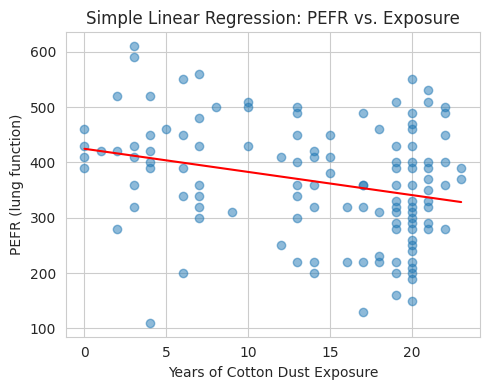

In [4]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(lung['Exposure'], lung['PEFR'], alpha=0.5)
x_line = np.linspace(lung['Exposure'].min(), lung['Exposure'].max(), 100)
y_line = simple_model.params['Intercept'] + simple_model.params['Exposure'] * x_line
ax.plot(x_line, y_line, color='red')
ax.set_xlabel('Years of Cotton Dust Exposure')
ax.set_ylabel('PEFR (lung function)')
ax.set_title('Simple Linear Regression: PEFR vs. Exposure')
plt.tight_layout()
plt.savefig('outputs/simple_regression.png', dpi=110)
plt.show()


**Reading the output.** The negative slope means more years of dust
exposure is associated with lower lung function — consistent with the known
occupational-health effect. The scatter around the line shows the fit isn't
perfect (R² isn't 1); other unmeasured factors (age, smoking, individual
lung capacity) also influence PEFR.


### 1.1 Fitted Values and Residuals

**Theory.** For every data point, the model produces a **fitted value**
(the prediction on the regression line) and a **residual** (actual −
fitted — the leftover error the line doesn't explain). Residuals are the
raw material for almost every regression diagnostic: if a model is a good
fit, residuals should look like patternless random noise centered at zero.


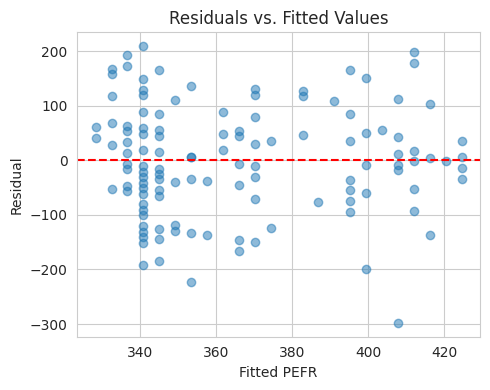

In [5]:
lung_fit = lung.copy()
lung_fit['fitted'] = simple_model.fittedvalues
lung_fit['residual'] = simple_model.resid

fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(lung_fit['fitted'], lung_fit['residual'], alpha=0.5)
ax.axhline(0, color='red', linestyle='--')
ax.set_xlabel('Fitted PEFR')
ax.set_ylabel('Residual')
ax.set_title('Residuals vs. Fitted Values')
plt.tight_layout()
plt.savefig('outputs/residuals_vs_fitted.png', dpi=110)
plt.show()


**Reading the output.** The residuals scatter fairly evenly above and
below zero without an obvious funnel or curve shape — a rough (if imperfect)
sign the linear model's core assumptions aren't badly violated here.


## 2. Multiple Linear Regression

**Theory.** Real outcomes rarely depend on just one input. Multiple linear
regression extends the idea to several predictors:
`Y = b0 + b1*X1 + b2*X2 + ... + bn*Xn`.
Each coefficient `bi` is now interpreted as "the effect of Xi *holding all
other predictors constant*" — this is what lets regression separate the
individual contribution of correlated real-world factors. We use
`house_sales.csv` (King County home sales) to predict `AdjSalePrice` from
several house characteristics.


In [6]:
house = pd.read_csv(HOUSE_CSV, sep='\t')
predictors = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 'Bedrooms', 'BldgGrade']
house_model_data = house[predictors + ['AdjSalePrice']].dropna()
house_model_data.describe()


,SqFtTotLiving,SqFtLot,Bathrooms,Bedrooms,BldgGrade,AdjSalePrice
count,22687.000000,2.268700e+04,22687.000000,22687.000000,22687.000000,2.268700e+04
mean,2080.165734,1.174633e+04,2.176500,3.367744,7.680963,5.652333e+05
std,913.742170,2.901602e+04,0.768027,0.904379,1.180464,3.854029e+05
min,370.000000,4.940000e+02,0.000000,0.000000,3.000000,3.368000e+03
25%,1420.000000,4.800000e+03,1.750000,3.000000,7.000000,3.605630e+05
50%,1910.000000,7.200000e+03,2.250000,3.000000,7.000000,4.713150e+05
75%,2540.000000,9.794000e+03,2.500000,4.000000,8.000000,6.494110e+05
max,10740.000000,1.024068e+06,8.000000,33.000000,13.000000,1.164486e+07


In [7]:
formula = 'AdjSalePrice ~ ' + ' + '.join(predictors)
house_model = ols(formula, data=house_model_data).fit()
house_model.params


Intercept       -521871.368188
SqFtTotLiving       228.830604
SqFtLot              -0.060467
Bathrooms        -19442.840398
Bedrooms         -47769.955185
BldgGrade        106106.963079
dtype: float64

**Reading the output.** The `SqFtTotLiving` and `BldgGrade` (build
quality grade) coefficients are typically the strongest positive drivers of
sale price, while `SqFtLot` (lot size) usually contributes much less per
unit — city lot size matters far less to price than the size of the house
itself.


### 2.1 Assessing the Model: RMSE and R²

**Theory.**
- **RMSE (Root Mean Squared Error)** — the typical size of a prediction
  error, in the same units as Y. Smaller is better.
- **R² (coefficient of determination)** — the proportion of variance in Y
  explained by the model, ranging from 0 (no explanatory power) to 1
  (perfect fit). Note: R² *always* increases (or stays flat) when you add
  more predictors, even useless ones — which is why **adjusted R²**, which
  penalizes model complexity, is often preferred for comparing models with
  different numbers of predictors.


In [8]:
residuals = house_model.resid
rmse = np.sqrt(np.mean(residuals ** 2))

print(f"RMSE:          {rmse:,.0f}")
print(f"R-squared:     {house_model.rsquared:.3f}")
print(f"Adj R-squared: {house_model.rsquared_adj:.3f}")


RMSE:          261,220
R-squared:     0.541
Adj R-squared: 0.540


**Reading the output.** An RMSE in the tens of thousands of dollars
means typical predictions are off by roughly that much — useful context for
judging whether the model is "good enough" for its intended use (e.g., a
rough valuation tool vs. a precise appraisal).


## 3. Factor (Categorical) Variables in Regression

**Theory.** Regression needs numbers, but many useful predictors are
categories (e.g., property type). The standard trick is **one-hot / dummy
encoding**: create a 0/1 indicator column for each category level except one
(the "reference level", absorbed into the intercept). Each dummy's
coefficient is then interpreted as "the price difference vs. the reference
category, holding other predictors constant".


In [9]:
house_cat_data = house[predictors + ['PropertyType', 'AdjSalePrice']].dropna()

formula_cat = 'AdjSalePrice ~ ' + ' + '.join(predictors) + ' + C(PropertyType)'
house_model_cat = ols(formula_cat, data=house_cat_data).fit()
house_model_cat.params


Intercept                          -446841.366312
C(PropertyType)[T.Single Family]    -84678.216295
C(PropertyType)[T.Townhouse]       -115121.979216
SqFtTotLiving                          223.373629
SqFtLot                                 -0.070368
Bathrooms                           -15979.013473
Bedrooms                            -50889.732185
BldgGrade                           109416.305161
dtype: float64

**Reading the output.** The `C(PropertyType)` coefficients show the
price premium or discount of each property type relative to the reference
category (alphabetically first, by default) — e.g., single-family homes
typically show a different baseline price than multiplexes or townhouses,
even after accounting for size and quality via the other predictors.


## 4. Interpreting the Regression Equation

**Theory.**
- **Confounding variable** — a variable correlated with both the predictor
  and the outcome, which can create a *misleading* coefficient if omitted.
  Classic example: ice cream sales and drowning deaths are correlated, but
  the real confounder is hot weather driving both.
- **Interaction effect** — when the effect of one predictor *depends on the
  level of another* (e.g., extra square footage might add more value in an
  expensive zip code than a cheap one). Modeled by adding a product term
  `X1 * X2` to the regression.


In [10]:
# Interaction: does the value of an extra square foot of living space
# depend on the building quality grade?
interaction_model = ols('AdjSalePrice ~ SqFtTotLiving * BldgGrade', data=house_model_data).fit()
interaction_model.params


Intercept                  625479.508998
SqFtTotLiving                -418.843132
BldgGrade                  -45832.486177
SqFtTotLiving:BldgGrade        69.193483
dtype: float64

**Reading the output.** A statistically meaningful interaction
coefficient on `SqFtTotLiving:BldgGrade` would mean square footage is worth
*more per square foot* in higher-grade homes than in lower-grade ones —
i.e., size and quality amplify each other's effect on price rather than
contributing independently.


## 5. Regression Diagnostics

**Theory.** A fitted regression is only trustworthy if its underlying
assumptions roughly hold. Key things to check:
- **Influential values** — a small number of points (often with extreme X
  values) can disproportionately pull the fitted line toward themselves.
  **Cook's distance** flags such points.
- **Heteroskedasticity** — when residual spread is *not* constant across
  the range of fitted values (e.g., errors grow for more expensive houses).
  Violates a core regression assumption and can make standard errors
  unreliable.
- **Non-normality of residuals** — checked with a QQ-plot of the residuals;
  matters most for the validity of statistical inference (p-values, CIs),
  less for pure prediction accuracy.


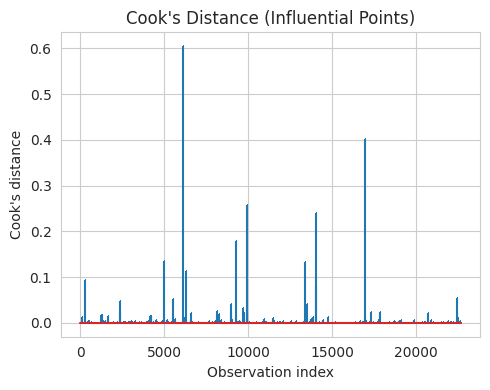

Number of highly influential points (Cook's D > 4/n): 915 out of 22687


In [11]:
influence = house_model.get_influence()
cooks_d = influence.cooks_distance[0]

fig, ax = plt.subplots(figsize=(5, 4))
ax.stem(np.arange(len(cooks_d)), cooks_d, markerfmt=',')
ax.set_xlabel('Observation index')
ax.set_ylabel("Cook's distance")
ax.set_title("Cook's Distance (Influential Points)")
plt.tight_layout()
plt.savefig('outputs/cooks_distance.png', dpi=110)
plt.show()

print(f"Number of highly influential points (Cook's D > 4/n): "
      f"{(cooks_d > 4 / len(cooks_d)).sum()} out of {len(cooks_d)}")


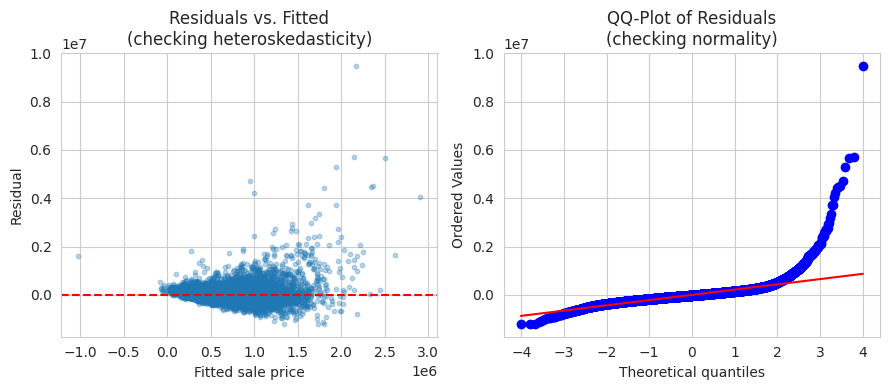

In [12]:
fig, axes = plt.subplots(ncols=2, figsize=(9, 4))

# Heteroskedasticity check
axes[0].scatter(house_model.fittedvalues, house_model.resid, alpha=0.3, s=10)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Fitted sale price')
axes[0].set_ylabel('Residual')
axes[0].set_title('Residuals vs. Fitted\n(checking heteroskedasticity)')

# Normality check
import scipy.stats as sstats
sstats.probplot(house_model.resid, dist='norm', plot=axes[1])
axes[1].set_title('QQ-Plot of Residuals\n(checking normality)')

plt.tight_layout()
plt.savefig('outputs/regression_diagnostics.png', dpi=110)
plt.show()


**Reading the output.** The residuals-vs-fitted plot typically fans
out wider for higher-priced homes — a classic **heteroskedasticity**
pattern, common for monetary outcomes (errors scale with the price level).
The QQ-plot usually shows heavier tails than a perfect normal distribution,
driven by a handful of unusually over/under-priced homes. Neither problem
necessarily ruins the model for prediction purposes, but both mean the
model's p-values and confidence intervals should be interpreted cautiously.


## Summary

| Concept | What it tells you |
|---|---|
| Simple linear regression | Predict Y from one X using a best-fit line |
| Multiple linear regression | Predict Y from several X's, holding others constant |
| RMSE | Typical prediction error size (same units as Y) |
| R² / Adjusted R² | Proportion of variance explained; adjusted penalizes extra predictors |
| Factor variables | Encode categories as 0/1 dummy columns |
| Confounding | An omitted variable can distort a coefficient's meaning |
| Interaction | One predictor's effect can depend on another predictor's level |
| Cook's distance | Flags individual points with outsized influence on the fit |
| Heteroskedasticity | Non-constant residual spread — a violated regression assumption |

The overarching lesson of Chapter 4: **a regression coefficient's headline
number is only meaningful together with its diagnostics** — RMSE/R² tell you
how good the predictions are, while residual plots and influence measures
tell you whether the fitted line can actually be trusted to mean what its
coefficients seem to say.
